# World Happiness Report Analysis — 01 Exploratory Data Analysis

An **EDA / visualization** project: what makes countries happy — the 2019 World Happiness Report scores 156 countries and breaks the score into six contributing factors. This notebook covers the data overview — shape, types, missing values, and the univariate distributions that frame the deeper analysis in notebook 02.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df=utils.load_data()
print('shape:',df.shape)
df.head()

shape: (156, 10)


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,2019
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,2019
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,2019
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,2019
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,2019


## 1. Structure & dtypes

In [2]:
print(df.dtypes.value_counts().to_dict())
df.info()

{dtype('float64'): 7, dtype('int64'): 2, dtype('O'): 1}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
 9   Year                          156 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 12.3+ KB


## 2. Missing values

In [3]:
mr=utils.missing_report(df)
print('columns with missing values:',len(mr))
print(mr.head(10).to_string())

columns with missing values: 0
Empty DataFrame
Columns: [missing, pct]
Index: []


## 3. Numeric distributions

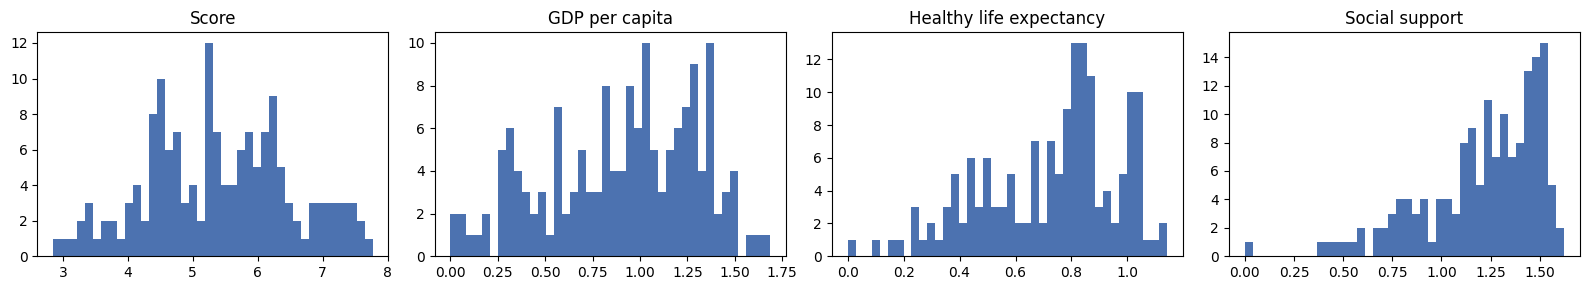

,Score,GDP per capita,Healthy life expectancy,Social support
count,156.00,156.00,156.00,156.00
mean,5.41,0.91,0.73,1.21
std,1.11,0.40,0.24,0.30
min,2.85,0.00,0.00,0.00
25%,4.54,0.60,0.55,1.06
50%,5.38,0.96,0.79,1.27
75%,6.18,1.23,0.88,1.45
max,7.77,1.68,1.14,1.62


In [4]:
num=['Score', 'GDP per capita', 'Healthy life expectancy', 'Social support']
num=[c for c in num if c in df.columns]
fig,ax=plt.subplots(1,len(num),figsize=(4*len(num),3))
ax=np.atleast_1d(ax)
for a,c in zip(ax,num):
    a.hist(df[c].dropna(),bins=40,color='#4c72b0'); a.set_title(c)
plt.tight_layout(); plt.show()
df[num].describe().round(2)

## 4. Top categories

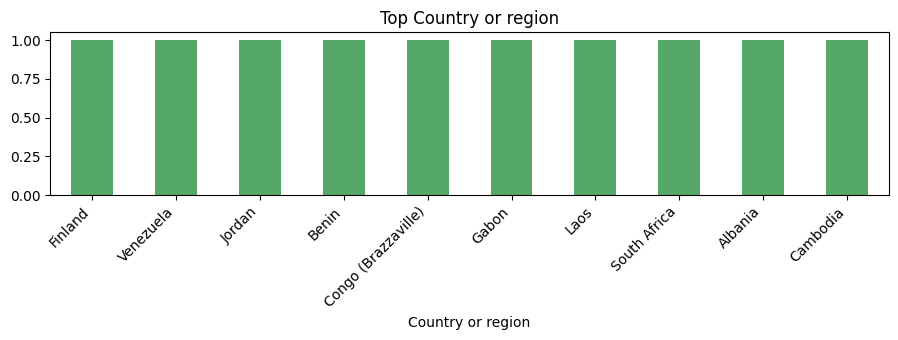

Country or region
Finland                1
Venezuela              1
Jordan                 1
Benin                  1
Congo (Brazzaville)    1
Gabon                  1
Laos                   1
South Africa           1
Albania                1
Cambodia               1


In [5]:
vc=utils.top_counts(df['Country or region'],10)
fig,ax=plt.subplots(figsize=(9,3.5)); vc.plot(kind='bar',ax=ax,color='#55a868'); ax.set_title('Top Country or region'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 5. Summary

The overview above (size, missingness, distributions, dominant categories) frames the domain questions answered in notebook **02 — Analysis**, where the real insights and headline numbers (reported in the README) come from.